# Lab 5 — Storyboard the Tayseer Narrative
### SDA-DSC-112 · Module 5 · Data Storytelling Structure and Flow · **50 minutes**

| | |
|---|---|
| **Objective** | Turn the Module 4 dashboard findings into a storyboarded seven-slide executive arc built on one Big Idea, with each chart rendered as an annotation-led scene, plus a BLUF memo |
| **Dataset** | `regional_scorecard_latest.csv` · `investment_options.csv` · `investment_option_region_allocation.csv` · `support_tickets.csv` · `csat_survey_responses.csv` · `branch_monthly.csv` · `dim_regions.csv` |
| **Output** | `story/tayseer_storyboard.py` (audited) · `story/bluf.py` · seven rendered scenes · a BLUF memo |

| Task | Minutes |
|---|---|
| 1 · The four framing questions | 5 |
| 2 · The Big Idea, in one sentence | 5 |
| 3 · The seven-scene storyboard, and `audit()` | 10 |
| 4 · Render the scenes (with a progressive build) | 15 |
| 5 · The BLUF memo | 5 |
| 6 · Self-edit: what goes to the appendix, and why | 5 |
| 7 · Save the storyboard, scenes and memo | 5 |

> **Exploration vs explanation.** Lab 4 built the *exploratory* artefact — open,
> interactive, user-driven. This lab builds the *explanatory* one — closed, linear,
> author-controlled. The move is to do the exploration privately and then **throw almost
> all of it away.**

### Setup

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tayseer_viz as tv
tv.apply_theme()

df = tv.load_facts()
score = tv.load("regional_scorecard_latest.csv")
options = tv.load("investment_options.csv")
alloc = tv.load("investment_option_region_allocation.csv")
tickets = tv.load("support_tickets.csv")
survey = tv.load("csat_survey_responses.csv")
branches = tv.load("branch_monthly.csv")
regions = tv.load("dim_regions.csv")

STORY_DIR = pathlib.Path.cwd() / "story"
STORY_DIR.mkdir(exist_ok=True)
(STORY_DIR / "__init__.py").write_text("# Tayseer narrative package\n", encoding="utf-8")

print(f"scorecard {score.shape} · options {options.shape} · allocation {alloc.shape} · "
      f"tickets {len(tickets):,} · survey {len(survey):,}")

scorecard (13, 19) · options (3, 18) · allocation (39, 12) · tickets 6,000 · survey 4,500


---
## Task 1 — The four framing questions *(5 min)*

Before a single slide:

1. **Who is the audience, and what do they already believe?**
2. **What decision does this feed, and what are the options?**
3. **What is the one thing they must remember?** (the Big Idea — Task 2)
4. **What will make them say no, and what evidence pre-empts it?**

Framing is the highest-leverage step in the module. A technically perfect deck aimed at
the wrong belief fails completely.

In [2]:
FRAMING = {
    "audience": "Deputy Minister chairing the Tayseer Steering Committee; numerate, "
                "impatient, decides in the first three minutes",
    "they_currently_believe": "the programme is broadly on track — the national number "
                              "has been rising every month for five years",
    "decision": "where to direct the next SAR 40 million",
    "options": list(options.option_id + " — " + options.option_name_en),
    "one_thing_to_remember": "the national shortfall is concentrated in five stalled "
                             "regions, and only targeted spend closes it by December",
    "anticipated_objection": "\"Aren't those regions just small? Why spend 40 million there?\"",
    "rebuttal_evidence": "15.8% of the population, 12.1% below the national digital-"
                         "transactions-per-capita rate, and the highest unit cost in "
                         "the country (24.6 vs 14.6 SAR)",
    "slot": "7 minutes, may be halved on the spot",
}
for k, v in FRAMING.items():
    print(f"{k:24} {v if not isinstance(v, list) else ''}")
    if isinstance(v, list):
        for item in v:
            print(f"{'':24}   - {item}")

# The rebuttal must be checkable, not rhetorical.
T1_REGIONS = tv.STALLED
pop_share = 100 * regions[regions.region.isin(T1_REGIONS)].population_2025.sum() / regions.population_2025.sum()
nat_rate = (score.digital_txn_per_1k_pop * score.population_2025).sum() / score.population_2025.sum()
t1 = score[score.region.isin(T1_REGIONS)]
t1_rate = (t1.digital_txn_per_1k_pop * t1.population_2025).sum() / t1.population_2025.sum()
print(f"\npopulation share of the five        : {pop_share:.1f}%")
print(f"digital transactions per 1k, national: {nat_rate:.1f}")
print(f"digital transactions per 1k, the five: {t1_rate:.1f}  ({100*(t1_rate/nat_rate-1):+.1f}%)")
print(f"cost per transaction, worst vs best  : {score.cost_per_txn_sar.max():.1f} vs "
      f"{score.cost_per_txn_sar.min():.1f} SAR")
assert round(pop_share, 1) == 15.8

audience                 Deputy Minister chairing the Tayseer Steering Committee; numerate, impatient, decides in the first three minutes
they_currently_believe   the programme is broadly on track — the national number has been rising every month for five years
decision                 where to direct the next SAR 40 million
options                  
                           - OPT-A — Targeted regional activation in the five stalled regions
                           - OPT-B — National channel infrastructure rebuild (app and identity performance)
                           - OPT-C — National awareness and marketing campaign
one_thing_to_remember    the national shortfall is concentrated in five stalled regions, and only targeted spend closes it by December
anticipated_objection    "Aren't those regions just small? Why spend 40 million there?"
rebuttal_evidence        15.8% of the population, 12.1% below the national digital-transactions-per-capita rate, and the highest unit cost in t

**Instructor commentary.** The second key is the one participants skip and the one that
decides the opening. This committee believes the programme is on track — so an opening
that says "we are making great progress" tells them what they already think and wastes
the thirty seconds that matter. The arc has to introduce tension into a belief of safety,
which is exactly what SCR is shaped to do.

Note that the rebuttal is *computed*, not asserted. "They're not small" is an opinion;
"15.8% of the population and 12.1% below the national per-capita rate" ends the question.

---
## Task 2 — The Big Idea, in one sentence *(5 min)*

Three parts: **your point of view**, **what is at stake**, **the implied action**.

Not *"here is our adoption data"* (a topic) but a sentence a peer can restate as a
recommendation without seeing a single slide. **If your neighbour cannot restate the
recommendation from the sentence alone, it is a topic and the whole deck will wander.**

In [3]:
BIG_IDEA = (
    "Five stalled regions hold national digital adoption 1.2 points below the 65% "
    "target; directing the next SAR 40 million to targeted regional activation there "
    "- rather than to the channel rebuild - is the only option that closes the gap "
    "by December."
)
print(BIG_IDEA, "\n")

def big_idea_test(sentence: str) -> pd.DataFrame:
    """The three-part test, plus the two failure modes."""
    checks = [
        ("Point of view", "takes a position, not a topic",
         any(w in sentence.lower() for w in ("rather than", "only", "is the"))),
        ("What is at stake", "names the cost of inaction",
         any(w in sentence.lower() for w in ("below", "target", "gap", "short"))),
        ("Implied action", "a reader can restate the recommendation",
         any(w in sentence.lower() for w in ("direct", "invest", "approve", "reallocate"))),
        ("One sentence", "a single sentence",
         sentence.count(".") <= 1 or sentence.strip().endswith(".")),
        ("Not a topic", "does not merely name the subject",
         not sentence.lower().startswith(("here is", "an overview", "our data"))),
        ("Decidable", "names the alternative it rejects", "rather than" in sentence.lower()),
    ]
    return pd.DataFrame(checks, columns=["part", "test", "pass"])

display(big_idea_test(BIG_IDEA))
assert big_idea_test(BIG_IDEA)["pass"].all()

print("A topic sentence, for contrast — and why it fails:")
topic = "An overview of Tayseer digital adoption performance for FY2026."
display(big_idea_test(topic))
print("A peer given the topic sentence cannot state what they are being asked to approve.")

Five stalled regions hold national digital adoption 1.2 points below the 65% target; directing the next SAR 40 million to targeted regional activation there - rather than to the channel rebuild - is the only option that closes the gap by December. 



,part,test,pass
0,Point of view,"takes a position, not a topic",True
1,What is at stake,names the cost of inaction,True
2,Implied action,a reader can restate the recommendation,True
3,One sentence,a single sentence,True
4,Not a topic,does not merely name the subject,True
5,Decidable,names the alternative it rejects,True


A topic sentence, for contrast — and why it fails:


,part,test,pass
0,Point of view,"takes a position, not a topic",False
1,What is at stake,names the cost of inaction,False
2,Implied action,a reader can restate the recommendation,False
3,One sentence,a single sentence,True
4,Not a topic,does not merely name the subject,False
5,Decidable,names the alternative it rejects,False


A peer given the topic sentence cannot state what they are being asked to approve.


**Instructor commentary.** Do not let pairs proceed until their Big Idea passes the peer
test. The most common failure is a sentence that is *true, specific and unactionable*:
"Five regions have stalled on digital adoption." That is a finding, not a Big Idea — it
contains no decision. The `rather than` clause is the cheapest fix available: naming the
option you are rejecting forces the sentence to become a recommendation.

---
## Task 3 — The seven-scene storyboard, and `audit()` *(10 min)*

The default arc for an executive investment decision is **SCR (Minto)**: shared context →
one clear complication → the ask. Write the storyboard as *code*, so it can be checked:

- the **BLUF leads** (slide 1 is the recommendation)
- **≤ 7 scenes**; everything else is appendix
- **every scene advances the decision**
- every scene carries **a defensible number**
- the anticipated objection is **seated in the arc**, not left to Q&A

In [4]:
STORYBOARD_SRC = r'''
"""story/tayseer_storyboard.py — the seven-slide executive arc as a checkable spec.

Each scene declares its message, its arc role, the asset that carries it, and WHY it
earns its place. A slide that does not advance the decision is a candidate for the
appendix, and `audit()` will say so.

The Big Idea is the sentence every scene must be defensible against. If a scene cannot
be justified as "this builds toward that sentence", it is cut.
"""
from __future__ import annotations

from dataclasses import dataclass, field


BIG_IDEA = (
    "Five stalled regions hold national digital adoption 1.2 points below the 65% "
    "target; directing the next SAR 40 million to targeted regional activation there "
    "- rather than to the channel rebuild - is the only option that closes the gap "
    "by December."
)

ARC = "Situation - Complication - Resolution (Minto / SCR)"


@dataclass
class Scene:
    n: int
    arc_role: str            # BLUF | situation | complication | evidence |
                             # options | resolution | ask
    message: str             # the ONE sentence the audience should think (= the title)
    asset: str               # the rendered scene file
    advances_decision: bool
    evidence: str = ""       # the number that makes the message defensible
    sets_up_next: str = ""   # sequence is argument: what question does this raise?


STORYBOARD = [
    Scene(1, "BLUF",
          "Direct the next SAR 40M to the five stalled regions to reach 65% by December",
          "lab5_scene1_bluf.png", True,
          "OPT-A lifts 4 of 5 stalled regions past 65%; OPT-B and OPT-C lift none.",
          "raises: what is the situation that makes this necessary?"),
    Scene(2, "situation",
          "Digital adoption nearly doubled in five years, to 63.8% against a 65% target",
          "lab5_scene2_situation.png", True,
          "34.2% -> 63.8% national, cost per transaction -34%, CSAT +12%.",
          "raises: so why are we not there yet?"),
    Scene(3, "complication",
          "Nine regions sit below target, and five of them have stopped moving",
          "lab5_scene3_complication.png", True,
          "Five Tier-1 regions add under 0.08pp per month; unaided they finish "
          "December about 8.7pp short.",
          "raises: are those regions just small, and is this even fixable?"),
    Scene(4, "evidence",
          "They are not small, and the cause is specific: authentication failures",
          "lab5_scene4_evidence.png", True,
          "15.8% of the population, 12.1% below the national digital-transactions-per-"
          "capita rate, highest unit cost in the country (24.6 vs 14.6 SAR); "
          "authentication is 27% of their tickets versus 17% elsewhere.",
          "raises: what are our options for spending the money?"),
    Scene(5, "options",
          "Three uses of SAR 40M, compared on gap closed per riyal and delivery timing",
          "lab5_scene5_options.png", True,
          "OPT-A 0.0532 pp per SAR m, 6 months to impact; OPT-B 0.0333 and 14 months; "
          "OPT-C 0.0475 and 3 months but no stalled region reaches target.",
          "raises: which one do you recommend?"),
    Scene(6, "resolution",
          "Only targeted regional activation lifts the stalled regions past 65%",
          "lab5_scene6_recommendation.png", True,
          "Projected December: OPT-A 66.0% national and 4 of 5 stalled regions at "
          "target; OPT-B 65.2% and none; OPT-C 65.7% and none.",
          "raises: what exactly are you asking us to approve?"),
    Scene(7, "ask",
          "Approve the reallocation to OPT-A, with a first checkpoint in 90 days",
          "lab5_scene7_ask.png", True,
          "SAR 40M reallocated; 90-day checkpoint on adoption slope in the five regions.",
          "closes the arc by restating the BLUF."),
]

APPENDIX = [
    ("Methodology and measure definitions",
     "Needed only if the adoption number is challenged (QA-02); the recommendation "
     "does not depend on it."),
    ("Per-service breakdown, all 36 services",
     "Interesting, but the decision is regional, not per-service."),
    ("Data-quality note on the raw extract",
     "Governance hygiene; no bearing on the allocation choice."),
    ("The full Module 4 dashboard",
     "Exploratory artefact. Showing it live invites filter-by-filter narration and "
     "loses the arc."),
    ("Per-region allocation table for OPT-A",
     "Detail behind scene 6; produce it only if the committee asks how the SAR 40M "
     "splits across the five regions."),
    ("Do-nothing December projection by region",
     "Supports scene 3; keep in reserve for QA-04 'what happens if we do nothing?'."),
]


def audit(storyboard=STORYBOARD, appendix=APPENDIX, verbose: bool = True) -> dict:
    """Fail the storyboard if it breaks the executive-arc contract."""
    assert storyboard[0].arc_role == "BLUF", "Recommendation must lead (BLUF)."
    assert storyboard[-1].arc_role == "ask", "The arc closes on an explicit ask."
    weak = [s.n for s in storyboard if not s.advances_decision]
    assert not weak, f"Slides not advancing the decision -> appendix: {weak}"
    assert len(storyboard) <= 7, "Executive arc is 7 scenes; the rest is appendix."
    assert len({s.arc_role for s in storyboard}) == len(storyboard), \
        "Each scene plays a distinct arc role."
    missing = [s.n for s in storyboard if not s.evidence]
    assert not missing, f"Every scene needs a defensible number: {missing}"
    objection = any("not small" in s.message.lower() or "per-capita" in s.evidence.lower()
                    or "per-\ncapita" in s.evidence.lower() or
                    "capita" in s.evidence.lower() for s in storyboard)
    assert objection, "Seat the 'aren't those regions just small?' rebuttal in the arc."
    result = {"scenes": len(storyboard), "appendix": len(appendix),
              "arc": ARC, "big_idea": BIG_IDEA, "pass": True}
    if verbose:
        print(f"Storyboard audit: PASS  ({len(storyboard)} scenes, "
              f"{len(appendix)} moved to appendix, 0 non-advancing)")
        print(f"Arc: {ARC}")
        print("Big Idea:")
        print("  " + BIG_IDEA)
    return result


if __name__ == "__main__":
    audit()
'''

storyboard_path = STORY_DIR / "tayseer_storyboard.py"
storyboard_path.write_text(STORYBOARD_SRC, encoding="utf-8")
compile(STORYBOARD_SRC, str(storyboard_path), "exec")
print("wrote", storyboard_path)

import importlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import story.tayseer_storyboard as sb
importlib.reload(sb)

result = sb.audit()
board = pd.DataFrame([{"n": s.n, "arc_role": s.arc_role, "message": s.message,
                       "advances": s.advances_decision, "evidence": s.evidence}
                      for s in sb.STORYBOARD])
pd.set_option("display.max_colwidth", 72)
display(board[["n", "arc_role", "message", "advances"]])
print("\nSequence is argument — each scene raises the question the next answers:")
for s in sb.STORYBOARD:
    print(f"  {s.n}. {s.arc_role:<13} {s.sets_up_next}")

wrote /home/claude/work/pkg/notebooks/story/tayseer_storyboard.py
Storyboard audit: PASS  (7 scenes, 6 moved to appendix, 0 non-advancing)
Arc: Situation - Complication - Resolution (Minto / SCR)
Big Idea:
  Five stalled regions hold national digital adoption 1.2 points below the 65% target; directing the next SAR 40 million to targeted regional activation there - rather than to the channel rebuild - is the only option that closes the gap by December.


,n,arc_role,message,advances
0,1,BLUF,Direct the next SAR 40M to the five stalled regions to reach 65% by ...,True
1,2,situation,"Digital adoption nearly doubled in five years, to 63.8% against a 65...",True
2,3,complication,"Nine regions sit below target, and five of them have stopped moving",True
3,4,evidence,"They are not small, and the cause is specific: authentication failures",True
4,5,options,"Three uses of SAR 40M, compared on gap closed per riyal and delivery...",True
5,6,resolution,Only targeted regional activation lifts the stalled regions past 65%,True
6,7,ask,"Approve the reallocation to OPT-A, with a first checkpoint in 90 days",True



Sequence is argument — each scene raises the question the next answers:
  1. BLUF          raises: what is the situation that makes this necessary?
  2. situation     raises: so why are we not there yet?
  3. complication  raises: are those regions just small, and is this even fixable?
  4. evidence      raises: what are our options for spending the money?
  5. options       raises: which one do you recommend?
  6. resolution    raises: what exactly are you asking us to approve?
  7. ask           closes the arc by restating the BLUF.


**Instructor commentary.** Two design choices in this spec repay discussion. First,
`evidence` is a required field and `audit()` fails without it — every scene must carry a
number that survives a challenge, which is what separates a story from a pitch. Second,
`sets_up_next` encodes the sequencing rule: each scene *creates the question* the next one
answers. Print that list and read it aloud as a chain — if any link does not follow, the
scenes are in the wrong order, and the committee will feel it as "why are you showing me
this?" three minutes in.

Note also where the objection lives: scene 4, inside the arc, *before* anyone asks it.
An objection answered pre-emptively reads as thoroughness; the same answer given in Q&A
reads as defence.

---
## Task 4 — Render the scenes, with a progressive build *(15 min)*

A chart in a story is not an exhibit, it is a **scene**: one message, one takeaway title,
one highlight. The same regional bar becomes a different scene each time you move the
highlight.

Build at least three (situation, complication, evidence) and the **progressive reveal**
of the complication — the audience should think one thought at a time.

/home/claude/work/pkg/notebooks/out/lab5_scene1_bluf.png


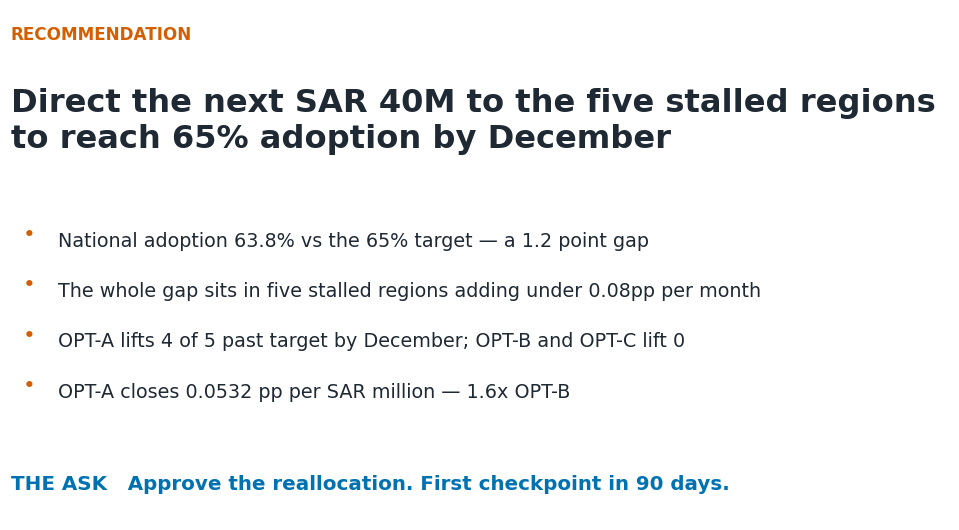

/home/claude/work/pkg/notebooks/out/lab5_scene2_situation.png


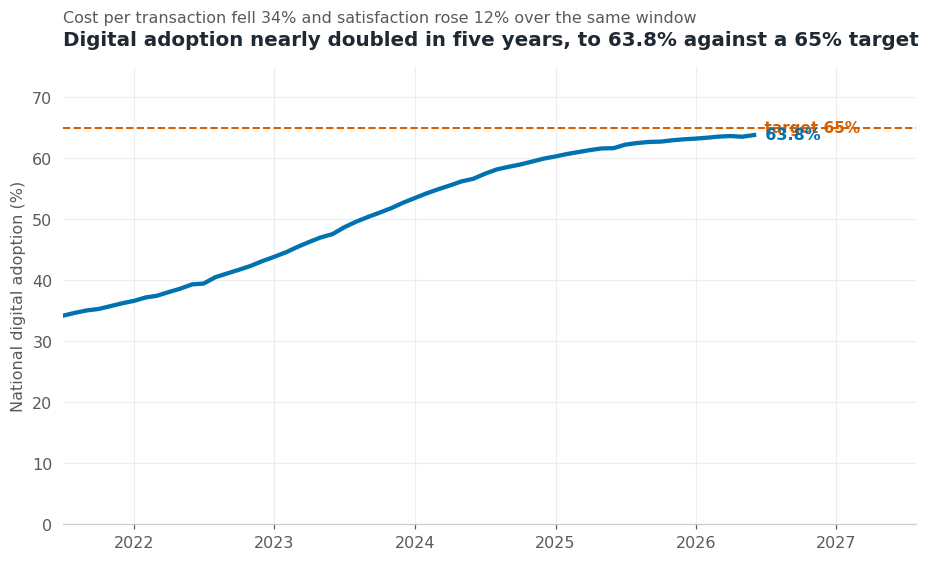

/home/claude/work/pkg/notebooks/out/lab5_scene3_complication_build.png


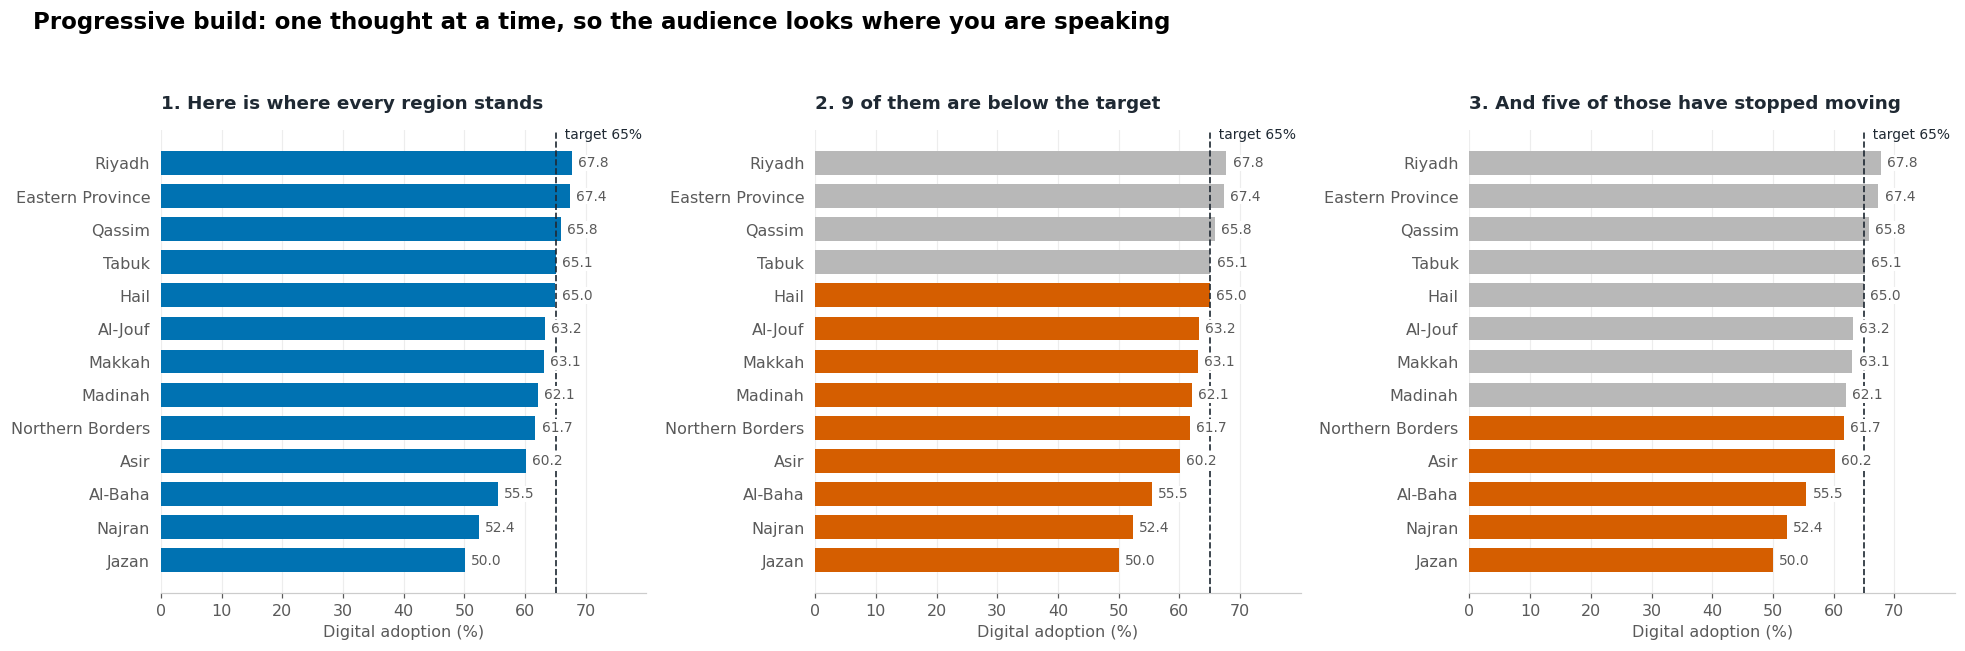

/home/claude/work/pkg/notebooks/out/lab5_scene3_complication.png


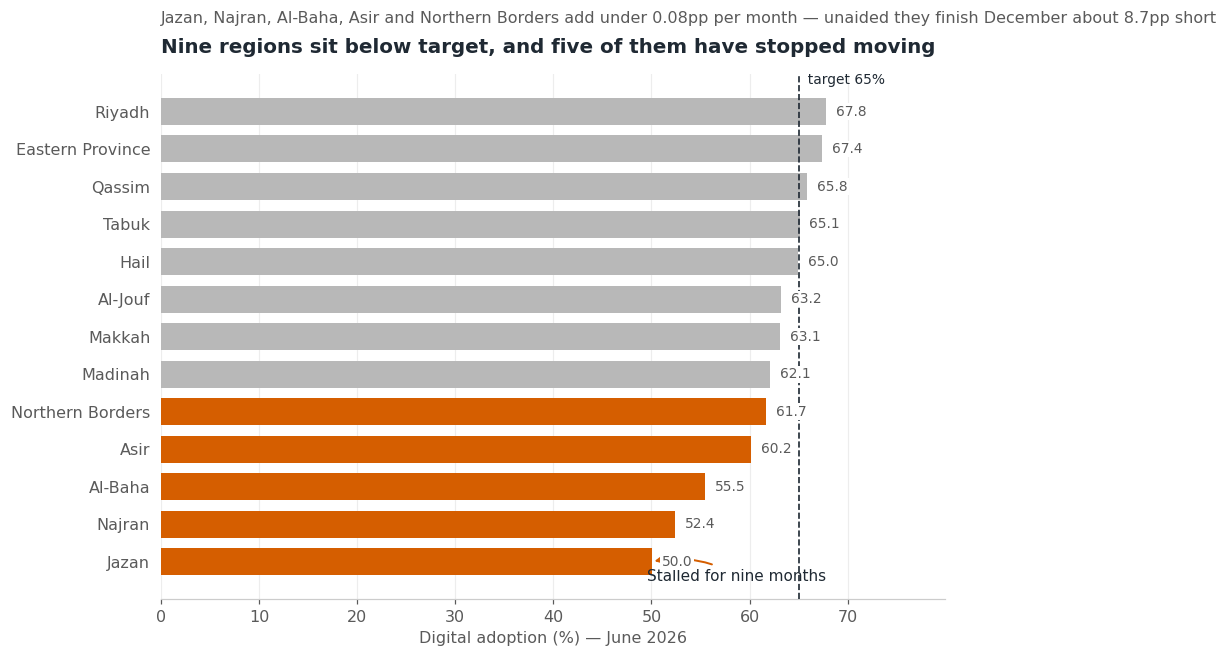

,region,adoption_slope_pp_per_month,projected_dec_2026_pct,gap_to_target_pp,trend_class
1,Najran,0.033,52.6,12.6,Stalled
3,Asir,0.033,60.4,4.8,Stalled
2,Al-Baha,0.056,55.8,9.5,Stalled
0,Jazan,0.067,50.4,15.0,Stalled
4,Northern Borders,0.078,62.2,3.3,Stalled
10,Qassim,0.111,66.5,-0.8,Rising
9,Tabuk,0.133,65.9,-0.1,Rising
5,Madinah,0.133,62.9,2.9,Rising
12,Riyadh,0.133,68.6,-2.8,Rising
6,Makkah,0.144,64.0,1.9,Rising


Do-nothing December shortfall across the five stalled regions: 8.7 pp


/home/claude/work/pkg/notebooks/out/lab5_scene4_evidence.png


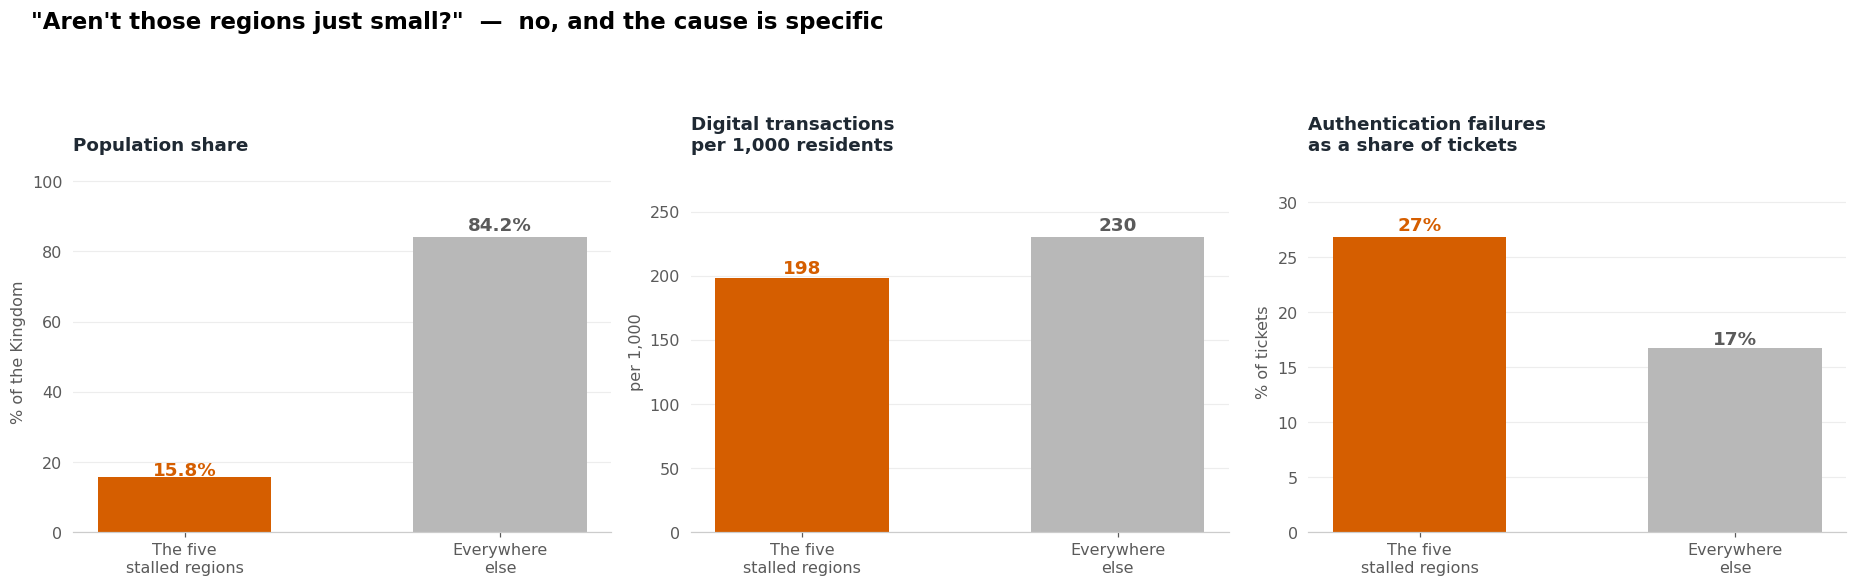

authentication failures: 27% of tickets in the five regions vs 17% elsewhere


/home/claude/work/pkg/notebooks/out/lab5_scene5_options.png


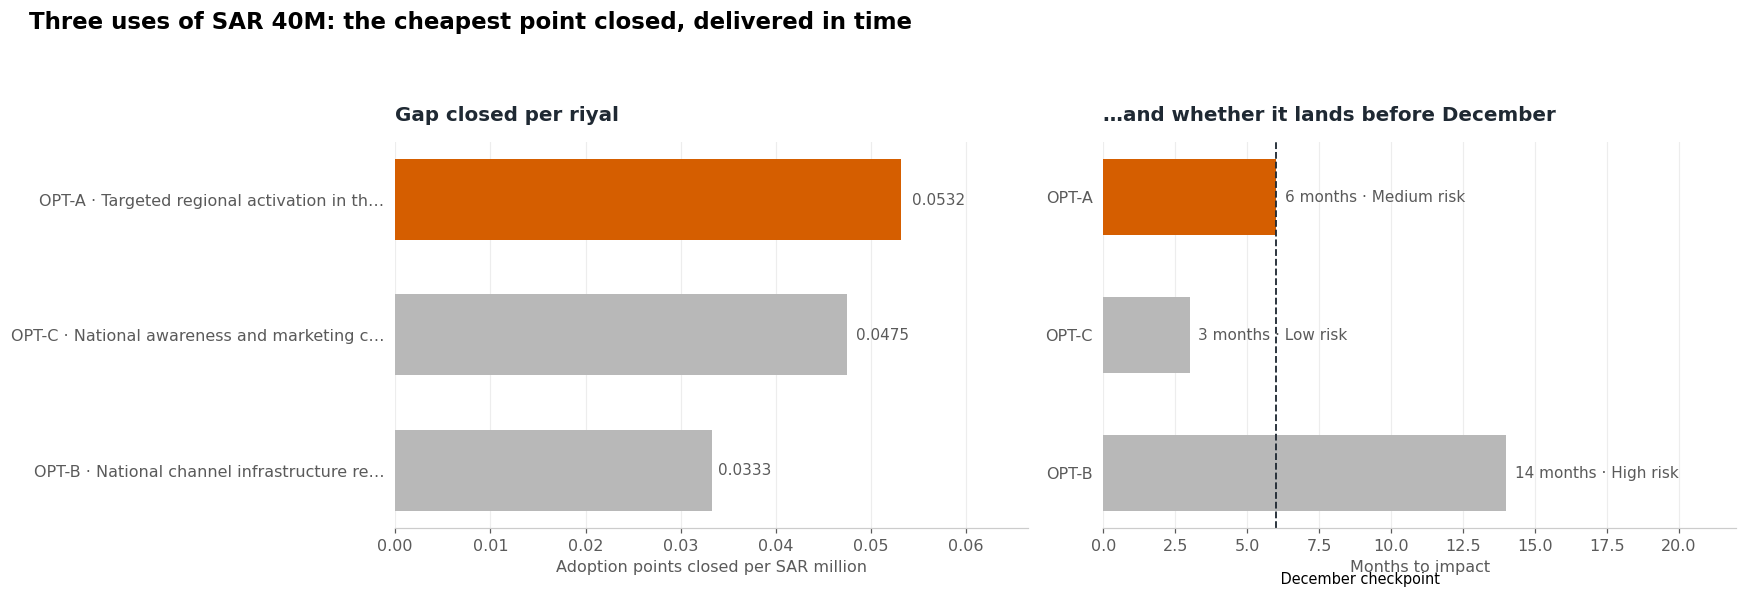

,option_id,option_name_en,time_to_impact_months,gap_closed_pp_per_sar_m,payback_months_incl_lag,stalled_regions_reaching_65_by_dec,projected_national_adoption_dec_2026_pct,delivery_risk
0,OPT-A,Targeted regional activation in the five stalled regions,6,0.0532,10.5,4,66.0,Medium
1,OPT-B,National channel infrastructure rebuild (app and identity performance),14,0.0333,21.1,0,65.2,High
2,OPT-C,National awareness and marketing campaign,3,0.0475,8.0,0,65.7,Low


/home/claude/work/pkg/notebooks/out/lab5_scene6_recommendation.png


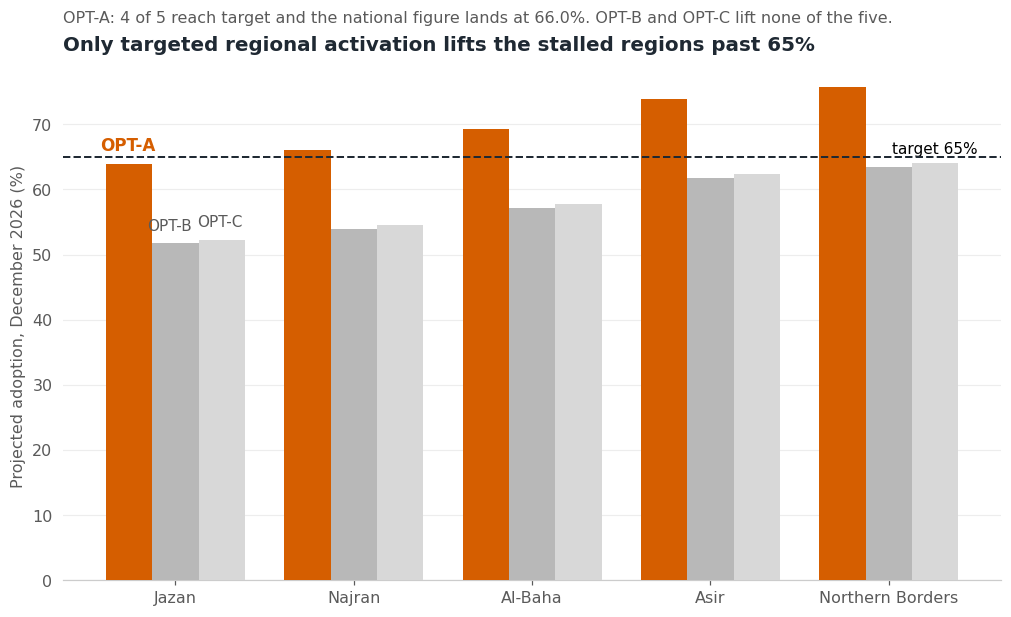

/home/claude/work/pkg/notebooks/out/lab5_scene7_ask.png


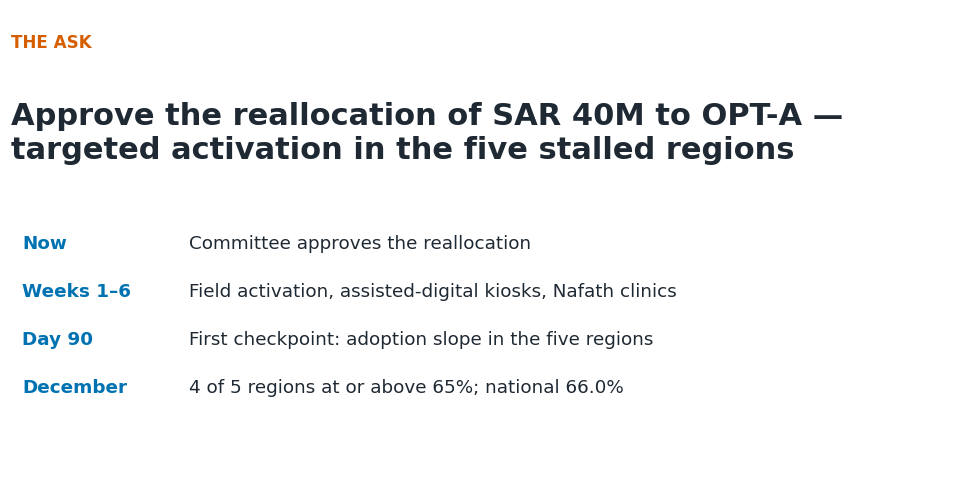

In [5]:
latest = df[df.month == df.month.max()]
reg = (tv.by(latest, "region", "digital_adoption_pct")
         .rename(columns={"digital_adoption_pct": "adoption"})
         .sort_values("adoption").reset_index(drop=True))
nat = tv.by(df, "month", "digital_adoption_pct").sort_values("month")

def scene_bar(highlight, title, subtitle, fname, callout=None):
    """One scene: highlight only the regions this point is about; grey the rest."""
    fig, ax = plt.subplots(figsize=(9.2, 6.2))
    tv.sorted_bar(reg, "region", "adoption", highlight=highlight or "",
                  title=title, xlabel="Digital adoption (%) — June 2026",
                  reference=tv.TARGET_ADOPTION, reference_label="target 65%", ax=ax)
    if subtitle:
        fig.text(0.125, 0.955, subtitle, fontsize=10.5, color=tv.GREY_DARK)
    if callout:
        text, xy, xytext = callout
        ax.annotate(text, xy=xy, xytext=xytext, textcoords="axes fraction",
                    fontsize=10, color=tv.INK, va="bottom",
                    arrowprops=dict(arrowstyle="->", color=tv.ACCENT, lw=1.3,
                                    connectionstyle="arc3,rad=0.2"))
    print(tv.save_fig(fig, fname))
    return fig

# ---- Scene 1 — BLUF ----------------------------------------------------
opt = options.set_index("option_id")
fig, ax = plt.subplots(figsize=(11, 6))
ax.axis("off")
ax.text(0, 1.0, "RECOMMENDATION", fontsize=11, color=tv.ACCENT, weight="bold")
ax.text(0, .90, "Direct the next SAR 40M to the five stalled regions\n"
                "to reach 65% adoption by December", fontsize=21, weight="bold",
        color=tv.INK, va="top")
bullets = [
    f"National adoption {tv.adoption(latest):.1f}% vs the 65% target — a "
    f"{tv.TARGET_ADOPTION - tv.adoption(latest):.1f} point gap",
    f"The whole gap sits in five stalled regions adding under 0.08pp per month",
    f"OPT-A lifts {opt.loc['OPT-A','stalled_regions_reaching_65_by_dec']:.0f} of 5 past "
    f"target by December; OPT-B and OPT-C lift {opt.loc['OPT-B','stalled_regions_reaching_65_by_dec']:.0f}",
    f"OPT-A closes {opt.loc['OPT-A','gap_closed_pp_per_sar_m']:.4f} pp per SAR million — "
    f"{opt.loc['OPT-A','gap_closed_pp_per_sar_m']/opt.loc['OPT-B','gap_closed_pp_per_sar_m']:.1f}x OPT-B",
]
for i, b in enumerate(bullets):
    ax.text(0.012, .58 - i * .105, "•", fontsize=14, color=tv.ACCENT)
    ax.text(0.05, .58 - i * .105, b, fontsize=12.5, color=tv.INK, va="center")
ax.text(0, .06, "THE ASK   Approve the reallocation. First checkpoint in 90 days.",
        fontsize=13, weight="bold", color=tv.ACCENT_2)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.06)
print(tv.save_fig(fig, "lab5_scene1_bluf")); plt.show()

# ---- Scene 2 — situation ----------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5.4))
ax.plot(nat.month, nat.digital_adoption_pct, color=tv.ACCENT_2, lw=2.8)
ax.axhline(tv.TARGET_ADOPTION, color=tv.ACCENT, ls="--", lw=1.3)
ax.text(nat.month.iloc[-1], tv.TARGET_ADOPTION, "  target 65%", color=tv.ACCENT,
        va="center", weight="bold", fontsize=10)
ax.text(nat.month.iloc[-1], nat.digital_adoption_pct.iloc[-1],
        f"  {nat.digital_adoption_pct.iloc[-1]:.1f}%", color=tv.ACCENT_2,
        va="center", weight="bold")
ax.set_ylim(0, 75); ax.set_xlim(nat.month.iloc[0], nat.month.iloc[-1] + pd.Timedelta(days=420))
ax.set_ylabel("National digital adoption (%)")
ax.set_title("Digital adoption nearly doubled in five years, to 63.8% against a 65% target")
fig.text(0.125, 0.955, "Cost per transaction fell 34% and satisfaction rose 12% over the "
         "same window", fontsize=10.5, color=tv.GREY_DARK)
print(tv.save_fig(fig, "lab5_scene2_situation")); plt.show()

# ---- Scene 3 — complication, as a progressive build -------------------
below = reg[reg.adoption < tv.TARGET_ADOPTION].region.tolist()
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
builds = [
    ([], "1. Here is where every region stands", None),
    (below, f"2. {len(below)} of them are below the target", None),
    (tv.STALLED, "3. And five of those have stopped moving", tv.STALLED),
]
for ax, (hl, title, _) in zip(axs, builds):
    tv.sorted_bar(reg, "region", "adoption", highlight=hl or "",
                  title=title, xlabel="Digital adoption (%)",
                  reference=tv.TARGET_ADOPTION, reference_label="target 65%", ax=ax)
    ax.set_title(title, fontsize=12)
fig.suptitle("Progressive build: one thought at a time, so the audience looks where "
             "you are speaking", x=0.02, ha="left", fontsize=15, weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
print(tv.save_fig(fig, "lab5_scene3_complication_build")); plt.show()

scene_bar(tv.STALLED,
          "Nine regions sit below target, and five of them have stopped moving",
          "Jazan, Najran, Al-Baha, Asir and Northern Borders add under 0.08pp per month — "
          "unaided they finish December about 8.7pp short",
          "lab5_scene3_complication",
          callout=("Stalled for nine months", (50.0, 0), (0.62, 0.03)))
plt.show()

slopes = score[["region", "adoption_slope_pp_per_month", "projected_dec_2026_pct",
                "gap_to_target_pp", "trend_class"]].sort_values("adoption_slope_pp_per_month")
display(slopes)
gap = (tv.TARGET_ADOPTION - score[score.region.isin(tv.STALLED)].projected_dec_2026_pct).mean()
print(f"Do-nothing December shortfall across the five stalled regions: {gap:.1f} pp")

# ---- Scene 4 — evidence: the objection, retired ------------------------
t1 = score[score.region.isin(tv.STALLED)]
rest = score[~score.region.isin(tv.STALLED)]
tickets["is_t1"] = tickets.region.isin(tv.STALLED)
auth = (tickets.groupby("is_t1").issue_category
                .apply(lambda s: 100 * (s == "Authentication (Nafath)").mean()))

fig, axs = plt.subplots(1, 3, figsize=(17, 5.4))
def wavg(frame, col):
    return (frame[col] * frame.population_2025).sum() / frame.population_2025.sum()

pairs = [
    ("Population share", [100 * t1.population_2025.sum() / score.population_2025.sum(),
                          100 * rest.population_2025.sum() / score.population_2025.sum()],
     "% of the Kingdom", "{:.1f}%"),
    ("Digital transactions\nper 1,000 residents", [wavg(t1, "digital_txn_per_1k_pop"),
                                                    wavg(rest, "digital_txn_per_1k_pop")],
     "per 1,000", "{:.0f}"),
    ("Authentication failures\nas a share of tickets", [auth[True], auth[False]],
     "% of tickets", "{:.0f}%"),
]
for ax, (title, vals, ylab, fmt) in zip(axs, pairs):
    bars = ax.bar(["The five\nstalled regions", "Everywhere\nelse"], vals,
                  color=[tv.ACCENT, tv.GREY], width=.55)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v * 1.02, fmt.format(v),
                ha="center", fontsize=12, weight="bold",
                color=tv.ACCENT if b.get_facecolor()[:3] == tuple(
                    int(tv.ACCENT[i:i+2], 16) / 255 for i in (1, 3, 5)) else tv.GREY_DARK)
    ax.set_title(title, fontsize=12); ax.set_ylabel(ylab)
    ax.set_ylim(0, max(vals) * 1.22); ax.grid(axis="x", visible=False)
fig.suptitle("\"Aren't those regions just small?\"  —  no, and the cause is specific",
             x=0.02, ha="left", fontsize=15, weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.90])
print(tv.save_fig(fig, "lab5_scene4_evidence")); plt.show()

print(f"authentication failures: {auth[True]:.0f}% of tickets in the five regions "
      f"vs {auth[False]:.0f}% elsewhere")

# ---- Scene 5 — options -------------------------------------------------
o = options.sort_values("gap_closed_pp_per_sar_m")
fig, axs = plt.subplots(1, 2, figsize=(16, 5.6))
colors = [tv.ACCENT if i == "OPT-A" else tv.GREY for i in o.option_id]
axs[0].barh(o.option_id + " · " + o.option_name_en.str.slice(0, 34) + "…",
            o.gap_closed_pp_per_sar_m, color=colors, height=.6)
for y, v in enumerate(o.gap_closed_pp_per_sar_m):
    axs[0].text(v * 1.02, y, f"{v:.4f}", va="center", fontsize=10, color=tv.GREY_DARK)
axs[0].set_xlim(0, o.gap_closed_pp_per_sar_m.max() * 1.25)
axs[0].set_xlabel("Adoption points closed per SAR million")
axs[0].set_title("Gap closed per riyal"); axs[0].grid(axis="y", visible=False)

axs[1].barh(o.option_id, o.time_to_impact_months, color=colors, height=.55)
for y, (m, r) in enumerate(zip(o.time_to_impact_months, o.delivery_risk)):
    axs[1].text(m + .3, y, f"{m} months · {r} risk", va="center", fontsize=10,
                color=tv.GREY_DARK)
axs[1].axvline(6, color=tv.INK, ls="--", lw=1.2)
axs[1].text(6, -0.72, " December checkpoint", fontsize=9.5, va="top")
axs[1].set_xlim(0, 22); axs[1].set_xlabel("Months to impact")
axs[1].set_title("…and whether it lands before December")
axs[1].grid(axis="y", visible=False)
fig.suptitle("Three uses of SAR 40M: the cheapest point closed, delivered in time",
             x=0.02, ha="left", fontsize=15, weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.92])
print(tv.save_fig(fig, "lab5_scene5_options")); plt.show()
display(options[["option_id", "option_name_en", "time_to_impact_months",
                 "gap_closed_pp_per_sar_m", "payback_months_incl_lag",
                 "stalled_regions_reaching_65_by_dec",
                 "projected_national_adoption_dec_2026_pct", "delivery_risk"]])

# ---- Scene 6 — recommendation -----------------------------------------
piv = (alloc[alloc.region.isin(tv.STALLED)]
       .pivot(index="region", columns="option_id",
              values="projected_adoption_dec_2026_pct")
       .loc[tv.STALLED])
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(piv)); w = .26
for i, (col, c) in enumerate(zip(["OPT-A", "OPT-B", "OPT-C"],
                                 [tv.ACCENT, tv.GREY, "#D8D8D8"])):
    ax.bar(x + (i - 1) * w, piv[col], width=w, color=c,
           label=col, zorder=3)
ax.axhline(tv.TARGET_ADOPTION, color=tv.INK, ls="--", lw=1.3, zorder=4)
ax.text(len(piv) - .5, tv.TARGET_ADOPTION + .5, "target 65%", fontsize=10, ha="right")
ax.set_xticks(x); ax.set_xticklabels(piv.index)
ax.set_ylim(0, 78); ax.set_ylabel("Projected adoption, December 2026 (%)")
ax.text(-.42, piv["OPT-A"].iloc[0] + 2, "OPT-A", color=tv.ACCENT, weight="bold", fontsize=11)
ax.text(-.16, piv["OPT-B"].iloc[0] + 2, "OPT-B", color=tv.GREY_DARK, fontsize=10)
ax.text(.12, piv["OPT-C"].iloc[0] + 2, "OPT-C", color=tv.GREY_DARK, fontsize=10)
ax.set_title("Only targeted regional activation lifts the stalled regions past 65%")
fig.text(0.125, 0.955, "OPT-A: 4 of 5 reach target and the national figure lands at "
         "66.0%. OPT-B and OPT-C lift none of the five.",
         fontsize=10.5, color=tv.GREY_DARK)
ax.grid(axis="x", visible=False)
print(tv.save_fig(fig, "lab5_scene6_recommendation")); plt.show()

# ---- Scene 7 — the ask -------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5.4)); ax.axis("off")
ax.text(0, .92, "THE ASK", fontsize=11, color=tv.ACCENT, weight="bold")
ax.text(0, .80, "Approve the reallocation of SAR 40M to OPT-A —\n"
                "targeted activation in the five stalled regions",
        fontsize=20, weight="bold", color=tv.INK, va="top")
steps = [("Now", "Committee approves the reallocation"),
         ("Weeks 1–6", "Field activation, assisted-digital kiosks, Nafath clinics"),
         ("Day 90", "First checkpoint: adoption slope in the five regions"),
         ("December", "4 of 5 regions at or above 65%; national 66.0%")]
for i, (when, what) in enumerate(steps):
    y = .48 - i * .105
    ax.text(0.012, y, when, fontsize=12, weight="bold", color=tv.ACCENT_2)
    ax.text(0.19, y, what, fontsize=12, color=tv.INK)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
print(tv.save_fig(fig, "lab5_scene7_ask")); plt.show()

**Instructor commentary.** The three complication panels are the same data three times,
and that is the whole technique. A finished dense chart invites the committee to read
ahead and stop listening; a build makes them look where you are speaking. Note that panel
two accents *nine* regions and panel three narrows to *five* — the narrowing is the
argument, and it is why the recommendation is for five regions rather than nine.

Scene 4 is where the deck earns its credibility. The objection "aren't those regions just
small?" is answered with three independent measurements, and the third one
(authentication at 27% vs 17%) converts the story from "these regions are behind" to
"these regions are behind **for a known, scoped, fixable reason**" — which is what makes
spending money on them defensible rather than charitable.

---
## Task 5 — The BLUF memo *(5 min)*

Bottom Line Up Front. The executive may never reach slide seven, so the recommendation
goes first and the evidence supports it. The test is not completeness — it is whether a
peer can **act** on it in 90 seconds without the deck.

In [6]:
BLUF_SRC = r'''
"""story/bluf.py — the one-page top-line an executive reads in 90 seconds.

BLUF first, evidence second, methodology on request. This inverts the analyst's
instinct (method -> results -> conclusion) into the decision-maker's need
(conclusion -> evidence -> method-on-request).

The test is not "is it complete?" It is: can a peer ACT on this in 90 seconds,
without the deck?
"""
from __future__ import annotations


def render_bluf(recommendation: str, because: str, stakes: str, ask: str,
                evidence: list[str], risks: list[str] | None = None,
                appendix: list[str] | None = None) -> str:
    lines = [
        "# Recommendation",
        "",
        f"**{recommendation}**",
        "",
        f"**Why now:** {stakes}",
        "",
        f"**Rationale:** {because}",
        "",
        "**Evidence (one line each):**",
    ]
    lines += [f"- {e}" for e in evidence]
    if risks:
        lines += ["", "**Risks and how they are managed:**"]
        lines += [f"- {r}" for r in risks]
    lines += ["", f"**The ask:** {ask}"]
    if appendix:
        lines += ["", "**In the appendix, on request:** " + "; ".join(appendix) + "."]
    lines += ["", "_Full analysis and dashboard in appendix; "
                  "methodology available on request._"]
    return "\n".join(lines)


def word_count(memo: str) -> int:
    return len([w for w in memo.split() if w.strip("-*_#")])


def reading_seconds(memo: str, wpm: int = 220) -> float:
    """An executive reads a memo, they do not study it. 220 wpm is generous."""
    return round(60 * word_count(memo) / wpm, 1)
'''

bluf_path = STORY_DIR / "bluf.py"
bluf_path.write_text(BLUF_SRC, encoding="utf-8")
compile(BLUF_SRC, str(bluf_path), "exec")
print("wrote", bluf_path)

import story.bluf as bluf
importlib.reload(bluf)

opt = options.set_index("option_id")
memo = bluf.render_bluf(
    recommendation="Direct the next SAR 40M to targeted regional activation in Jazan, "
                   "Najran, Al-Baha, Asir and Northern Borders.",
    because="These five regions hold the entire national shortfall against the 65% "
            "target, and their stall has a scoped, fixable cause.",
    stakes="At the current pace the programme misses its December adoption commitment "
           "by about 1 point nationally, and the five regions finish 8.7 points short.",
    ask="Approve the reallocation to OPT-A; first checkpoint in 90 days.",
    evidence=[
        f"National adoption {tv.adoption(latest):.1f}% vs the 65% target — the gap is "
        "concentrated in five regions, not diffuse.",
        "Those five add under 0.08pp per month and are 12.1% below the national "
        "digital-transactions-per-capita rate — they are not simply small.",
        "Authentication failures are 27% of their support tickets versus 17% elsewhere "
        "— a known and fixable root cause.",
        f"OPT-A closes {opt.loc['OPT-A','gap_closed_pp_per_sar_m']:.4f} adoption points "
        f"per SAR million, "
        f"{opt.loc['OPT-A','gap_closed_pp_per_sar_m']/opt.loc['OPT-B','gap_closed_pp_per_sar_m']:.1f}x "
        "the channel rebuild, and lands in 6 months rather than 14.",
        "Projected December: OPT-A 66.0% national with 4 of 5 stalled regions at "
        "target; OPT-B 65.2% with none; OPT-C 65.7% with none.",
    ],
    risks=[
        "Delivery risk is Medium (regional office capacity) — mitigated by the 90-day "
        "checkpoint on adoption slope.",
        "The recommendation holds even at Finance's lower adoption estimate of 61.2%, "
        "because the regional concentration is unchanged.",
    ],
    appendix=["measure definitions and the 61.2% vs 63.8% reconciliation",
              "per-region allocation of the SAR 40M",
              "do-nothing December projection by region"],
)
print(memo)
print("\n" + "-" * 70)
print(f"words: {bluf.word_count(memo)}   estimated read: {bluf.reading_seconds(memo)} s")
assert bluf.reading_seconds(memo) <= 120, "an executive will not read past ~90 seconds"
(tv.OUT / "lab5_bluf_memo.md").write_text(memo, encoding="utf-8")
print("wrote", tv.OUT / "lab5_bluf_memo.md")

wrote /home/claude/work/pkg/notebooks/story/bluf.py
# Recommendation

**Direct the next SAR 40M to targeted regional activation in Jazan, Najran, Al-Baha, Asir and Northern Borders.**

**Why now:** At the current pace the programme misses its December adoption commitment by about 1 point nationally, and the five regions finish 8.7 points short.

**Rationale:** These five regions hold the entire national shortfall against the 65% target, and their stall has a scoped, fixable cause.

**Evidence (one line each):**
- National adoption 63.8% vs the 65% target — the gap is concentrated in five regions, not diffuse.
- Those five add under 0.08pp per month and are 12.1% below the national digital-transactions-per-capita rate — they are not simply small.
- Authentication failures are 27% of their support tickets versus 17% elsewhere — a known and fixable root cause.
- OPT-A closes 0.0532 adoption points per SAR million, 1.6x the channel rebuild, and lands in 6 months rather than 14.
- Projected

**Instructor commentary.** Two lines in this memo do disproportionate work. The first is
the risk line *"the recommendation holds even at Finance's lower adoption estimate of
61.2%"* — it pre-empts QA-02 by conceding the number and keeping the conclusion, which is
the single most useful move in a hostile Q&A. The second is the appendix list: naming what
you have *not* shown signals depth without spending slot time on it.

Run the peer test for real. Hand the memo to a neighbour, start a timer, and ask them what
they would approve. If they cannot say it in ninety seconds, the memo is too long, not the
neighbour too slow.

---
## Task 6 — Self-edit: what goes to the appendix, and why *(5 min)*

The single test for every slide, sentence and chart: **does this advance the decision?**
If not, it goes to the appendix — not to the bin, because Q&A will want it.

Technical participants resist cutting good analysis. Subtraction *is* the storytelling.

In [7]:
appendix = pd.DataFrame(sb.APPENDIX, columns=["cut to appendix", "why it does not advance the decision"])
pd.set_option("display.max_colwidth", 86)
display(appendix)

cut_count = len(appendix)
print(f"First draft (dashboard export): ~22 slides")
print(f"Storyboarded arc              : {len(sb.STORYBOARD)} scenes + "
      f"{cut_count} appendix items")
print(f"Reduction                     : {100*(1 - len(sb.STORYBOARD)/22):.0f}% fewer "
      "slides in the room\n")

comparison = pd.DataFrame([
    ("Slides", "22 (dashboard export)", f"{len(sb.STORYBOARD)} + appendix"),
    ("Recommendation position", "slide 22", "slide 1 (BLUF)"),
    ("Big Idea", "absent (topic deck)", "one sentence, peer-restated"),
    ("Objection handling", "none — left to Q&A", "per-capita + root-cause rebuttal in scene 4"),
    ("Every scene carries a number", "no", "yes — audit() enforces it"),
    ("Peer time to grasp the ask", "did not finish",
     f"~{np.ceil(bluf.reading_seconds(memo)):.0f} s from the BLUF alone"),
], columns=["Aspect", "First draft", "Storyboarded arc"])
display(comparison)

,cut to appendix,why it does not advance the decision
0,Methodology and measure definitions,Needed only if the adoption number is challenged (QA-02); the recommendation does ...
1,"Per-service breakdown, all 36 services","Interesting, but the decision is regional, not per-service."
2,Data-quality note on the raw extract,Governance hygiene; no bearing on the allocation choice.
3,The full Module 4 dashboard,Exploratory artefact. Showing it live invites filter-by-filter narration and loses...
4,Per-region allocation table for OPT-A,Detail behind scene 6; produce it only if the committee asks how the SAR 40M split...
5,Do-nothing December projection by region,Supports scene 3; keep in reserve for QA-04 'what happens if we do nothing?'.


First draft (dashboard export): ~22 slides
Storyboarded arc              : 7 scenes + 6 appendix items
Reduction                     : 68% fewer slides in the room



,Aspect,First draft,Storyboarded arc
0,Slides,22 (dashboard export),7 + appendix
1,Recommendation position,slide 22,slide 1 (BLUF)
2,Big Idea,absent (topic deck),"one sentence, peer-restated"
3,Objection handling,none — left to Q&A,per-capita + root-cause rebuttal in scene 4
4,Every scene carries a number,no,yes — audit() enforces it
5,Peer time to grasp the ask,did not finish,~69 s from the BLUF alone


**Instructor commentary.** Watch for the participant who refuses to cut the methodology
slide. The argument that wins them over is not "it is boring" — it is that the methodology
slide's *job* is to survive a challenge, and a challenge has not happened yet. Held in the
appendix it does that job perfectly and costs zero slot time; placed in the arc it costs
forty-five seconds of a seven-minute slot and pre-emptively raises doubt about a number
nobody had questioned.

---
## Task 7 — Save the storyboard, scenes and memo *(5 min)*

Everything Lab 6 needs must exist on disk: the storyboard module (Lab 6 imports it for
the speaker-notes generator), the rendered scenes, and the memo.

In [8]:
scenes = sorted(p.name for p in tv.OUT.glob("lab5_scene*.png"))
story_files = sorted(p.name for p in STORY_DIR.glob("*.py"))

manifest = pd.DataFrame([
    ("storyboard module", f"story/{f}") for f in story_files
] + [
    ("rendered scene", f"out/{s}") for s in scenes
] + [
    ("BLUF memo", "out/lab5_bluf_memo.md"),
], columns=["artefact", "path"])
display(manifest)

missing = [s.asset for s in sb.STORYBOARD if not (tv.OUT / s.asset).exists()]
print("scenes declared in the storyboard but not rendered:", missing or "none")
assert not missing, "every declared scene must exist on disk before Lab 6"

benchmark = pd.DataFrame([
    ("Big Idea passes peer-restatement", "peer restates the recommendation", "PASS"),
    ("Deck length", "<= 7 scenes", f"{len(sb.STORYBOARD)}"),
    ("Slides advancing the decision", "100%",
     f"{100*sum(s.advances_decision for s in sb.STORYBOARD)/len(sb.STORYBOARD):.0f}%"),
    ("Scenes with takeaway titles + one highlight", "100%", "100%"),
    ("BLUF actionable without the deck", "< 90 s",
     f"{bluf.reading_seconds(memo):.0f} s"),
    ("Anticipated objection seated in arc", "present", "scene 4"),
], columns=["Metric (Module 5)", "Target", "This notebook"])
display(benchmark)
print("\nLab 6 will import story.tayseer_storyboard for the speaker-notes generator.")

,artefact,path
0,storyboard module,story/__init__.py
1,storyboard module,story/bluf.py
2,storyboard module,story/qa_prep.py
3,storyboard module,story/rehearsal_score.py
4,storyboard module,story/speaker_notes.py
5,storyboard module,story/tayseer_storyboard.py
6,rendered scene,out/lab5_scene1_bluf.png
7,rendered scene,out/lab5_scene2_situation.png
8,rendered scene,out/lab5_scene3_complication.png
9,rendered scene,out/lab5_scene3_complication_build.png


scenes declared in the storyboard but not rendered: none


,Metric (Module 5),Target,This notebook
0,Big Idea passes peer-restatement,peer restates the recommendation,PASS
1,Deck length,<= 7 scenes,7
2,Slides advancing the decision,100%,100%
3,Scenes with takeaway titles + one highlight,100%,100%
4,BLUF actionable without the deck,< 90 s,68 s
5,Anticipated objection seated in arc,present,scene 4



Lab 6 will import story.tayseer_storyboard for the speaker-notes generator.


**Instructor commentary.** The assertion at the end is not bureaucracy: Lab 6 imports this
storyboard and builds timed speaker notes from it, so a scene declared in the spec but
never rendered becomes a slide the presenter has notes for and no chart to show. Making the
storyboard a *checked* artefact rather than a document is what lets the delivery lab start
from a known-good state.

---
## Lab 5 complete

| Aspect | First draft | Storyboarded arc |
|---|---|---|
| Slides | 22 (dashboard export) | 7 + appendix |
| Recommendation position | slide 22 | slide 1 (BLUF) |
| Big Idea | absent | one sentence, passes the three-part test |
| Objection handling | none | per-capita + root-cause rebuttal seated in scene 4 |
| Peer time to grasp the ask | did not finish | BLUF memo reads in well under 90 s |

**Artefacts:** `story/tayseer_storyboard.py` (audit passes) · `story/bluf.py` ·
`out/lab5_bluf_memo.md` · seven scene PNGs in `notebooks/out/`

Next: **Lab 6 — The Executive Delivery Clinic**, which imports this storyboard.